# Patch Metrics Demo

`patch_metrics` classifies tree clusters as linear (shelterbelts) vs non-linear (patches) and outputs
the skeleton length/width statistics for each patch.

In [1]:
from shelterbelts.utils.filepaths import get_filename
from shelterbelts.utils.visualisation import visualise_categories_sidebyside, visualise_categories
from shelterbelts.indices.patch_metrics import patch_metrics
from shelterbelts.indices.shelter_categories import shelter_categories_cmap, shelter_categories_labels

# Example data
buffer_file = get_filename('g2_26729_gullies_and_roads_buffer_categories.tif')

## Default Parameters

In [2]:
ds, df = patch_metrics(buffer_file)

Saved: ./TEST_assigned_labels.tif
Saved: ./TEST_ellipse_outlines.tif
Saved: ./TEST_shortest_path_raster.tif
Saved: ./TEST_perpendicular_raster.tif
Saved: ./TEST_shelterbelt_widths.tif
Saved: ./TEST_patch_metrics.csv
Saved: ./TEST_linear_categories.tif
Saved: ./TEST_linear_categories.png


In [3]:
df.head()

,label,ellipse_length,ellipse_width,ellipse len/width,perimeter,area,orientation_degrees,skeleton_width,skeleton_length,skeleton len/width,category_id,category_name
0,1,229.371710,95.404211,2.404210,991.091450,15010.0,79.246991,80.306837,192,2.390830,12.0,Patch Core
1,4,112.645713,38.917939,2.894442,501.209199,1041.0,-2.933969,6.122523,104,16.986461,15.0,Trees in Gullies
2,8,11.852863,6.858282,1.728255,31.313708,50.0,-58.108803,6.740043,8,1.186936,15.0,Trees in Gullies
3,9,18.375348,7.203346,2.550946,48.006097,83.0,-85.585708,7.210284,13,1.802980,15.0,Trees in Gullies
4,10,8.087055,5.455497,1.482368,19.692388,29.0,-52.581955,6.573452,6,0.912762,15.0,Trees in Gullies


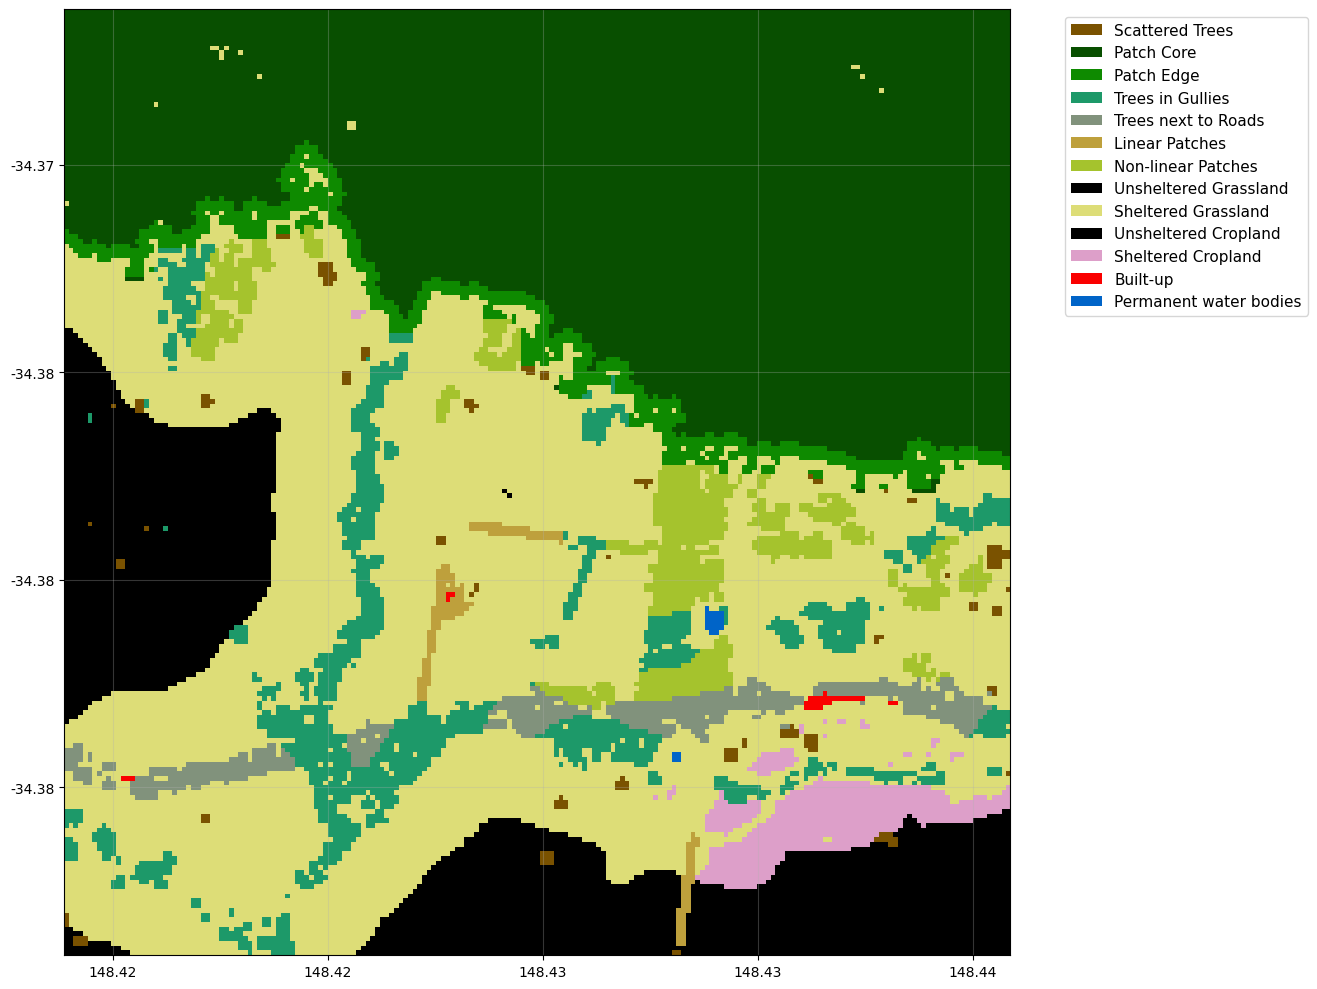

In [4]:
visualise_categories(
    ds['linear_categories'],
    colormap=shelter_categories_cmap,
    labels=shelter_categories_labels
)

## Changing min_shelterbelt_length and max_shelterbelt_width

Saved: ./TEST_assigned_labels.tif
Saved: ./TEST_ellipse_outlines.tif
Saved: ./TEST_shortest_path_raster.tif
Saved: ./TEST_perpendicular_raster.tif
Saved: ./TEST_shelterbelt_widths.tif
Saved: ./TEST_patch_metrics.csv
Saved: ./TEST_linear_categories.tif
Saved: ./TEST_linear_categories.png
Saved: ./TEST_assigned_labels.tif
Saved: ./TEST_ellipse_outlines.tif
Saved: ./TEST_shortest_path_raster.tif
Saved: ./TEST_perpendicular_raster.tif
Saved: ./TEST_shelterbelt_widths.tif
Saved: ./TEST_patch_metrics.csv
Saved: ./TEST_linear_categories.tif
Saved: ./TEST_linear_categories.png


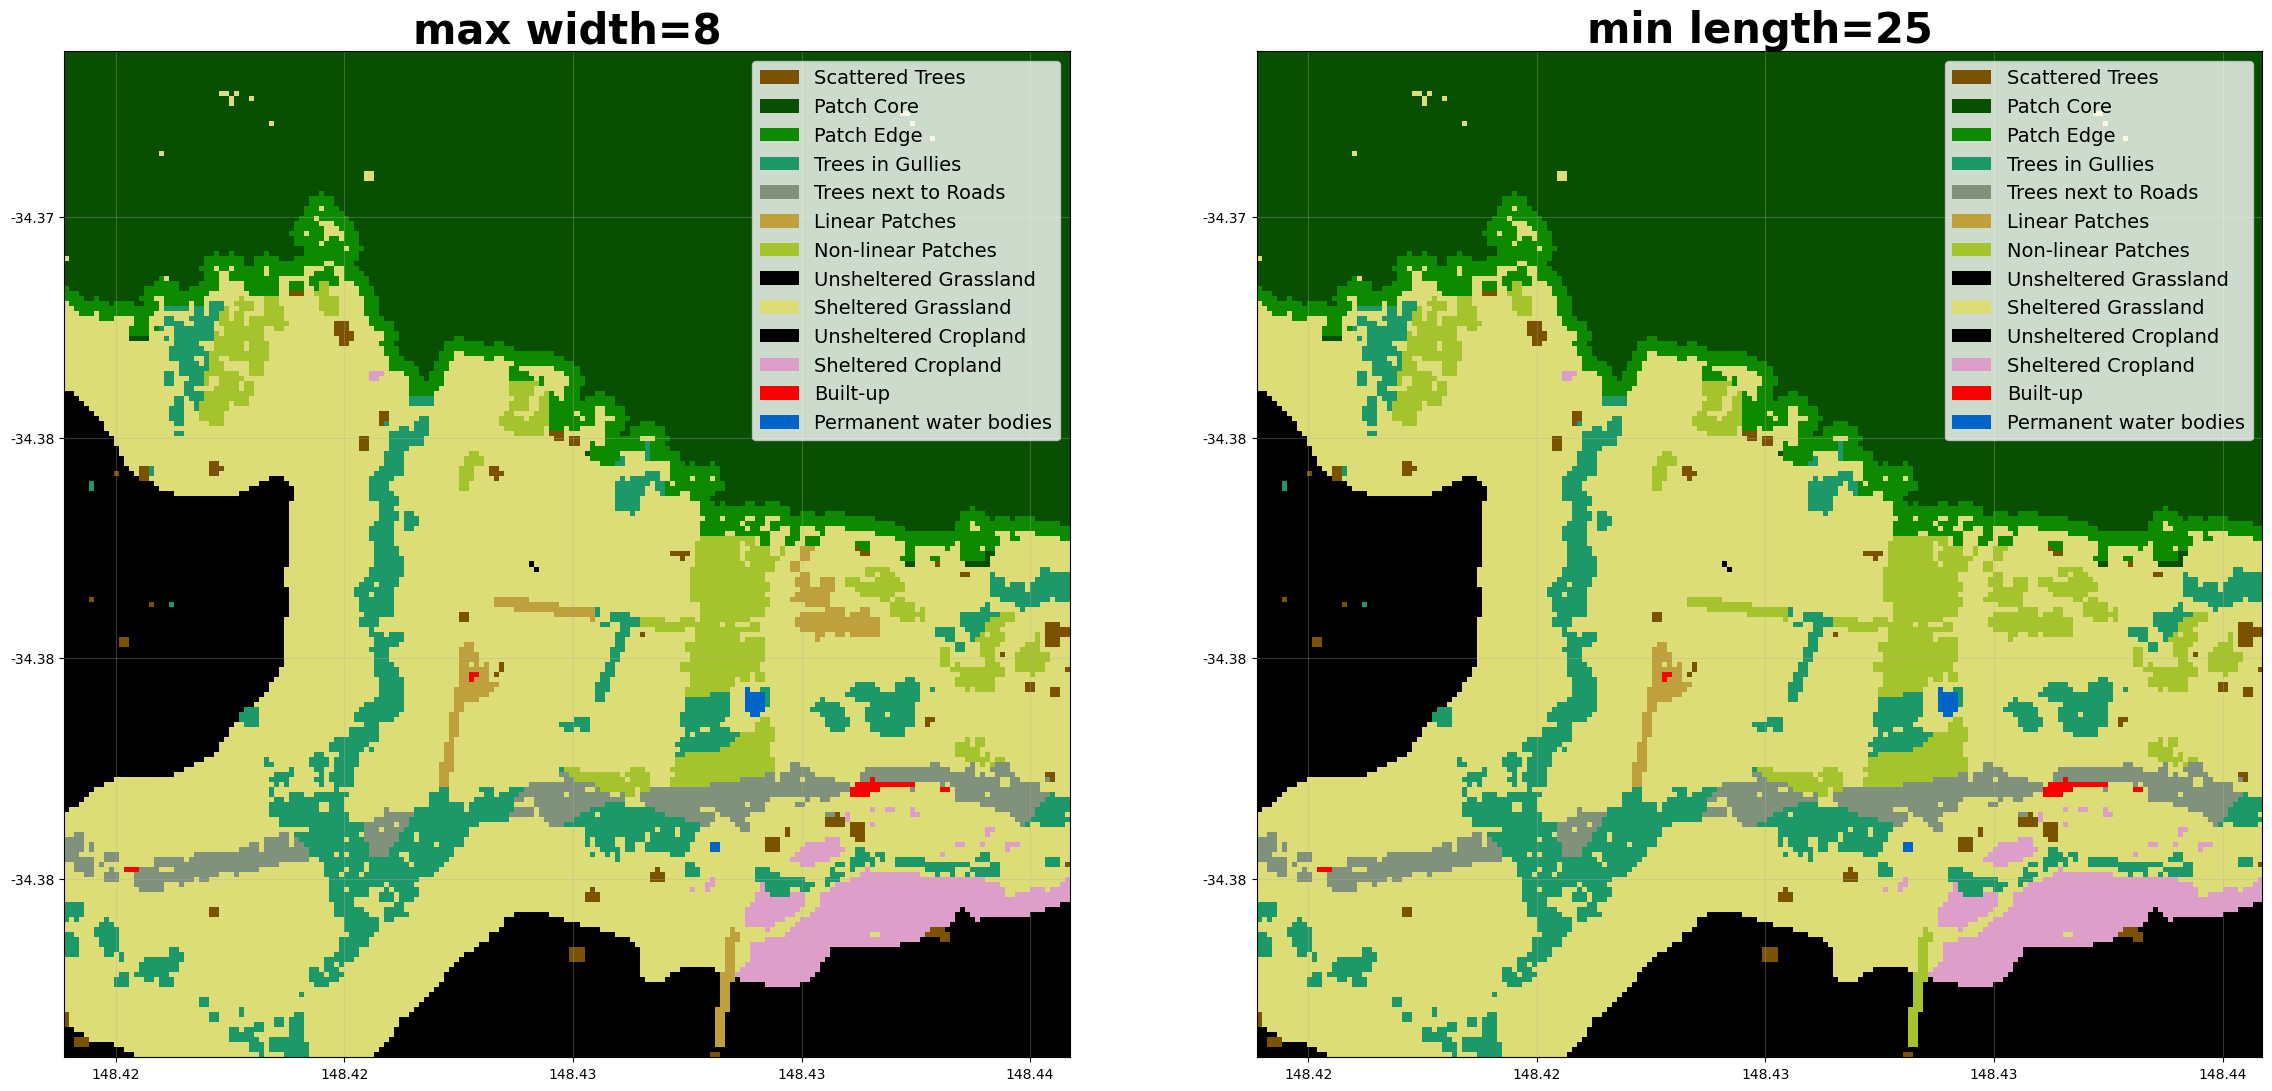

In [5]:
ds1, _ = patch_metrics(buffer_file, max_shelterbelt_width=8)
ds2, _ = patch_metrics(buffer_file, min_shelterbelt_length=25)
visualise_categories_sidebyside(
    ds1['linear_categories'], ds2['linear_categories'],
    colormap=shelter_categories_cmap, labels=shelter_categories_labels,
    title1="max width=8", title2="min length=25"
)

## Command Line Interface

In [6]:
!python -m shelterbelts.indices.patch_metrics --help

usage: patch_metrics.py [-h] [--outdir OUTDIR] [--stub STUB] [--no-plot]
                        [--no-save-csv] [--no-save-tif] [--no-save-labels]
                        [--min_shelterbelt_length MIN_SHELTERBELT_LENGTH]
                        [--max_shelterbelt_width MAX_SHELTERBELT_WIDTH]
                        [--min_patch_size MIN_PATCH_SIZE]
                        [--crop_pixels CROP_PIXELS]
                        buffer_data

positional arguments:
  buffer_data           Integer tif file generated by buffer_categories.py

options:
  -h, --help            show this help message and exit
  --outdir OUTDIR       Output directory for saving results (default: current
                        directory)
  --stub STUB           Prefix for output filenames (default: TEST)
  --no-plot             Disable PNG visualisation (default: enabled)
  --no-save-csv         Disable CSV output (default: enabled)
  --no-save-tif         Disable GeoTIFF output (default: enabled)
  --no-save-labels

In [7]:
!python -m shelterbelts.indices.patch_metrics {buffer_file} --stub command_line

Saved: ./command_line_assigned_labels.tif
Saved: ./command_line_ellipse_outlines.tif
Saved: ./command_line_shortest_path_raster.tif
Saved: ./command_line_perpendicular_raster.tif
Saved: ./command_line_shelterbelt_widths.tif
Saved: ./command_line_patch_metrics.csv
Saved: ./command_line_linear_categories.tif
Saved: ./command_line_linear_categories.png


In [8]:
!python -m shelterbelts.indices.patch_metrics {buffer_file} --min_shelterbelt_length 25 --max_shelterbelt_width 8 --stub command_line

Saved: ./command_line_assigned_labels.tif
Saved: ./command_line_ellipse_outlines.tif
Saved: ./command_line_shortest_path_raster.tif
Saved: ./command_line_perpendicular_raster.tif
Saved: ./command_line_shelterbelt_widths.tif
Saved: ./command_line_patch_metrics.csv
Saved: ./command_line_linear_categories.tif
Saved: ./command_line_linear_categories.png


### Cleanup
Remove the output files created by this notebook

In [9]:
# !rm *.tif
# !rm *.png
# !rm *.xml  # These get generated if you load the tifs in QGIS
# !rm *.csv